# Labeling

<a target="_blank" href="https://colab.research.google.com/github/pleyad/Summer-School-2026/blob/main/notebooks/XX_Labeling.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Housekeeping (no interaction required)

In [1]:
%pip install openrouter
# Is dotenv installed?

/home/bode-wsl/projects/summerschool26/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import random
import time
from pathlib import Path
import json
import pandas as pd
from tqdm.notebook import tqdm
from openrouter import OpenRouter

from dataclasses import dataclass
tqdm.pandas()

In [3]:
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
DATA_DIR = Path('/content/drive/MyDrive/ZBSummerSchool26/data') if IN_COLAB else Path('../data')
MODEL_NAME = "openai/gpt-5.4-mini"

In [4]:
def confirm(question: str = "Do you want to execute this cell?"):
    while True:
        response = input(f"{question} (y/n): ").lower()
        if response in ["y", "yes"]:
            return True
        elif response in ["n", "no"]:
            return False
        else:
            print("Please enter 'y' or 'n'.")

## Setup (Interaction required)

### Load the data

In [ ]:
### ⬇️⬇️⬇️ 💽 Adjust here if you want to continue with your own query
CORPUS_NAME = "armensteuer_and_similars"
LOAD_OWN_DATA = True
YOUR_NAME = "niclas"
### ⬆️⬆️⬆️

In [6]:
if IN_COLAB and LOAD_OWN_DATA: # and confirm("Do you want to mount your Google Drive?"):
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DATA_DIR, exist_ok=True)

#### <img src="https://cdn.simpleicons.org/googledrive" alt="💾" width=16> Load your own data from Google Drive

#### <img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=16> Load your own data from Google Drive

In [ ]:
if LOAD_OWN_DATA:
    # RAWDATA_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.parquet" # Use data from filtering module
    # raw_df = pd.read_parquet(RAWDATA_PATH)

    # SENTENCES_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.sentences.parquet" # Use data from filtering module
    # sentences_df = pd.read_parquet(SENTENCES_PATH)

    # raw_df = raw_df.join(sentences_df, on="id")

    LABELS_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.pp.label.{YOUR_NAME}.csv" # Use data from filtering module
    labels_df = pd.read_csv(LABELS_PATH)

In [8]:

if not LOAD_OWN_DATA:
    # RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.csv" 
    # raw_df = pd.read_csv(RAWDATA_ORIGIN_URL, index_col="id")

    RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.parquet"
    print(f"Loading raw data ...", end="\r")
    raw_df = pd.read_parquet(RAWDATA_ORIGIN_URL)

    SENTENCES_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.sentences.parquet"
    print(f"Loading sentences data ...", end="\r")
    sentences_df = pd.read_parquet(SENTENCES_URL)

    raw_df = raw_df.join(sentences_df)

### Enable LLM interaction

In [9]:
from openrouter import OpenRouter
import os
import dotenv
dotenv.load_dotenv()

with OpenRouter(
  # api_key=API_KEY,
  api_key=os.getenv("OPENROUTER_API_KEY"),
) as client:
  response = client.chat.send(
    model=MODEL_NAME,
    messages=[
      {
        "role": "user",
        "content": "What is the meaning of life?"
      }
    ]
  )

print(response.choices[0].message.content)

There isn’t one universally agreed meaning of life.

Different answers fit different worldviews:

- **Biological:** to survive and reproduce.
- **Philosophical:** to create meaning through choices, values, and relationships.
- **Religious/spiritual:** to serve God, grow morally, or achieve enlightenment.
- **Humanistic:** to reduce suffering, help others, and build a good life.
- **Personal:** to pursue what feels worthwhile to you.

A practical answer many people land on is: **the meaning of life is the meaning you make—through love, learning, purpose, and connection.**

If you want, I can also give you:
1. a **philosophical** answer,  
2. a **religious** answer, or  
3. a **short, poetic answer**.


### 

### Parsing

In [10]:
raw_df["year"] = pd.to_datetime(raw_df["date"], errors="coerce").dt.year

## Introduction to Prompting

## Hands-on:
Now try the following things:

1.   Change the user prompt and re-run the request.
2.   Change the system prompt to something completely random and re-run the request.

### Temperature and top-p
Let's go through each of these arguments one-by-one. Below you will see API calling code for the LLM with a slightly more complex prompt. Try out requests to this LLM where you:


1.   Vary the temperature parameter.
2. Vary the top-p parameter.

Your task is try to get the funniest and weirdest response possible from the model.

In order to prevent too excessive an output (and to protect our OpenAI budget!) we'll limit the output to a maximum of 50 tokens using the `max_tokens` argument; please do not change this.

In [11]:
# ⬇️⬇️⬇️ Adjust the system and user prompts here to see how it affects the output
longer_system_prompt = (
    "You are a political text classifier. Given a social media post, return a JSON object "
    "with exactly four fields: "
    "\"topic\" (a short label for the main topic, e.g. 'economy', 'healthcare', 'immigration'), "
    "\"sentiment\" (one of: 'positive', 'negative', 'neutral'), and "
    "\"is_political\" (true or false). "
    "Return only the JSON object, nothing else."
)
longer_user_prompt = (
    "Post: 'Can't believe they're cutting the healthcare budget again while giving tax breaks "
    "to billionaires. This government doesn't care about ordinary people.'"
)
# ⬆️⬆️⬆️

In [12]:
with OpenRouter(
  api_key=os.getenv("OPENROUTER_API_KEY"),
) as client:
    response = client.chat.send(
        model=MODEL_NAME,
        messages=[
        {"role": "system", "content": longer_system_prompt},
        {"role": "user", "content": longer_user_prompt}
        ],
        max_tokens=50,

        # ⬇️⬇️⬇️ Adjust these parameters to see how it affects the output
        temperature=1, # 0-1
        top_p=0.1 # 0-1
        # ⬆️⬆️⬆️
    )

output_text = response.choices[0].message.content  # take the output and extract the text response only

# parse and pretty-print the JSON output
parsed = json.loads(output_text)
print(json.dumps(parsed, indent=2))

{
  "topic": "healthcare",
  "sentiment": "negative",
  "is_political": true
}


## Parse the data from LabelStudio

In [13]:
if LOAD_OWN_DATA:
    LABELLED_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.labelled.csv" # Use data from filtering module
    labelled_df = pd.read_csv(LABELLED_PATH, index_col="id")


if not LOAD_OWN_DATA:
    RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.parquet"
    print(f"Loading raw data ...", end="\r")
    labelled_df = pd.read_parquet(RAWDATA_ORIGIN_URL)

FileNotFoundError: [Errno 2] No such file or directory: '../data/armensteuer_and_similars.filtered.labelled.csv'

In [31]:
# Only for development
labelled_df = pd.DataFrame({
    "id": range(20),
    "pseudo_paragraph": [
        "I love the new healthcare policy! It's going to help so many people.",
        "The economy is in shambles, and the government is doing nothing about it.",
        "Just had a sandwich for lunch. It was okay.",
        "The weather is nice today, perfect for a walk in the park.",
        "The new tax reform will burden middle-class families even further.",
        "Our community centre just got renovated — it looks amazing!",
        "Politicians keep promising change but nothing ever happens.",
        "I'm so proud of our local football team winning the championship!",
        "The immigration policy debate is getting more heated every day.",
        "Had a really productive meeting at work today.",
        "Rising inflation is making it impossible to afford groceries.",
        "The new park downtown is a great place for families to spend time.",
        "Government corruption is at an all-time high — something must change.",
        "Just finished reading a wonderful book, highly recommend it.",
        "Public transport has improved significantly in our city this year.",
        # "The military budget increase is a waste of taxpayer money.",
        # "My neighbour helped me fix my fence today, such a kind gesture.",
        # "Education funding cuts will damage the future of our children.",
        # "The local farmers market was packed with fresh produce this morning.",
        # "Climate change legislation is long overdue and the government keeps stalling.",
        "Just watched a fantastic movie, highly recommend it.",
        "The new library in town is a great addition for the community.",
        "Traffic congestion is getting worse every day.",
        "The healthcare system is underfunded and struggling to keep up with demand.",
        "Had a lovely dinner with friends last night."
    ],
    "label": [
        "positive",
        "negative",
        "neutral",
        "neutral",
        "negative",
        "positive",
        "negative",
        "positive",
        "neutral",
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "positive",
        # "negative",
        # "positive",
        # "negative",
        # "neutral",
        # "negative",
        None,
        None,
        None,
        None,
        None
    ]
})
labelled_df.set_index("id", inplace=True)

labelled_df_2 = pd.DataFrame({
    "id": range(20),
    "pseudo_paragraph": [
        "I love the new healthcare policy! It's going to help so many people.",
        "The economy is in shambles, and the government is doing nothing about it.",
        "Just had a sandwich for lunch. It was okay.",
        "The weather is nice today, perfect for a walk in the park.",
        "The new tax reform will burden middle-class families even further.",
        "Our community centre just got renovated — it looks amazing!",
        "Politicians keep promising change but nothing ever happens.",
        "I'm so proud of our local football team winning the championship!",
        "The immigration policy debate is getting more heated every day.",
        "Had a really productive meeting at work today.",
        "Rising inflation is making it impossible to afford groceries.",
        "The new park downtown is a great place for families to spend time.",
        "Government corruption is at an all-time high — something must change.",
        "Just finished reading a wonderful book, highly recommend it.",
        "Public transport has improved significantly in our city this year.",
        # "The military budget increase is a waste of taxpayer money.",
        # "My neighbour helped me fix my fence today, such a kind gesture.",
        # "Education funding cuts will damage the future of our children.",
        # "The local farmers market was packed with fresh produce this morning.",
        # "Climate change legislation is long overdue and the government keeps stalling.",
        "Just watched a fantastic movie, highly recommend it.",
        "The new library in town is a great addition for the community.",
        "Traffic congestion is getting worse every day.",
        "The healthcare system is underfunded and struggling to keep up with demand.",
        "Had a lovely dinner with friends last night."
    ],
    "label": [
        "positive",
        "negative",
        "neutral",
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "positive",
        # "negative",
        # "positive",
        # "negative",
        # "neutral",
        # "negative",
        None,
        None,
        None,
        None,
        None
    ]
})
labelled_df_2.set_index("id", inplace=True)

## Assess your labels and classification scheme by comparing the results of two human coders

❓ Maybe leave out this section? Students probably won't have second raters and it would only work with our data (which we would need to create).

In [24]:
# ⬇️⬇️⬇️ Adjust the categories according to your data
categories = {
    "positive": "The post expresses a positive sentiment.",
    "negative": "The post expresses a negative sentiment.",
    "neutral": "The post does not express a clear positive or negative sentiment."
}
# ⬆️⬆️⬆️

In [33]:
labelled_df

,pseudo_paragraph,label
id,,
0,I love the new healthcare policy! It's going t...,positive
1,"The economy is in shambles, and the government...",negative
2,Just had a sandwich for lunch. It was okay.,neutral
3,"The weather is nice today, perfect for a walk ...",neutral
4,The new tax reform will burden middle-class fa...,negative
5,Our community centre just got renovated — it l...,positive
6,Politicians keep promising change but nothing ...,negative
7,I'm so proud of our local football team winnin...,positive
8,The immigration policy debate is getting more ...,neutral


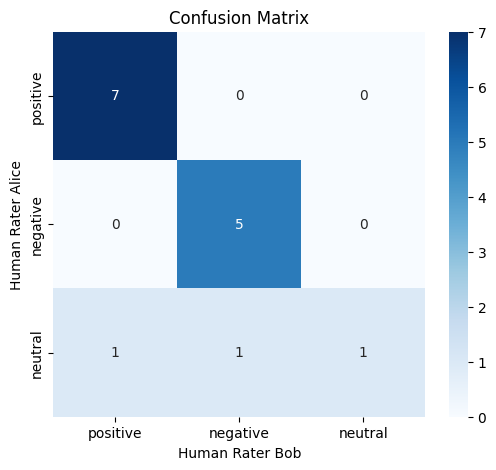

Cohen's Kappa: 0.7794
Matthews Correlation Coefficient: 0.7988


In [41]:
from sklearn.metrics import confusion_matrix, cohen_kappa_score, matthews_corrcoef
from matplotlib import pyplot as plt
import seaborn as sns

def evaluate_rater_agreement(labels_1: pd.Series, name_1: str, labels_2: pd.Series, name_2: str):

    mask = labels_1.notna() & labels_2.notna()
    labels_1 = labels_1[mask]
    labels_2 = labels_2[mask]

    labels = list(set(labels_1) | set(labels_2))

    cm = confusion_matrix(labels_1, labels_2, labels=labels)
    kappa = cohen_kappa_score(labels_1, labels_2, labels=labels)
    mcc = matthews_corrcoef(labels_1, labels_2)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel(name_2)
    plt.ylabel(name_1)
    plt.title('Confusion Matrix')
    plt.show()
    print(f"Cohen's Kappa: {kappa:.4f}")
    print(f"Matthews Correlation Coefficient: {mcc:.4f}")

evaluate_rater_agreement(labelled_df["label"], "Human Rater Alice", labelled_df_2["label"], "Human Rater Bob")

In [43]:
# Show disagreemnts
labelled_df[labelled_df["label"] != labelled_df_2["label"]]


,pseudo_paragraph,label
id,,
3,"The weather is nice today, perfect for a walk ...",neutral
8,The immigration policy debate is getting more ...,neutral
15,"Just watched a fantastic movie, highly recomme...",NaN
16,The new library in town is a great addition fo...,NaN
17,Traffic congestion is getting worse every day.,NaN
18,The healthcare system is underfunded and strug...,NaN
19,Had a lovely dinner with friends last night.,NaN


## Develop an LLM Labeller

In [15]:
unlabelled_df = labelled_df[labelled_df["label"].isna()].copy() 
gold_df = labelled_df[~labelled_df["label"].isna()].copy()

In [16]:
sample_size = min(len(gold_df), 20)
evaluation_size = min(10, sample_size // 2)
tuning_size = sample_size - evaluation_size

evaluation_df = gold_df.sample(evaluation_size, random_state=42)
tuning_df = gold_df.drop(evaluation_df.index)

In [17]:
evaluation_df

,id,pseudo_paragraph,label
9,9,Had a really productive meeting at work today.,positive
11,11,The new park downtown is a great place for fam...,positive
0,0,I love the new healthcare policy! It's going t...,positive
13,13,"Just finished reading a wonderful book, highly...",positive
5,5,Our community centre just got renovated — it l...,positive
8,8,The immigration policy debate is getting more ...,neutral
2,2,Just had a sandwich for lunch. It was okay.,neutral


In [18]:
# ⬇️⬇️⬇️ Adjust the categories according to your data
categories = {
    "positive": "The post expresses a positive sentiment.",
    "negative": "The post expresses a negative sentiment.",
    "neutral": "The post does not express a clear positive or negative sentiment."
}
# ⬆️⬆️⬆️

In [ ]:
# This response format forces the model to always return an expected structure
response_format = {
            "type": "json_schema",
            "json_schema": {
                "name": "political_text_classification",
                "strict": True,
                "schema": {
            "type": "object",
            "properties": {
                "label": {
                    "type": "string",
                    "enum": list(categories.keys())
                },
                "reasoning": {
                    "type": "string"
                }
            },
            "required": ["label", "reasoning"],
            "additionalProperties": False
        }
    }
}

def get_model_response(post: str) -> dict:
    system_prompt = (

        # ⬇️⬇️⬇️ Adjust the system prompt to guide the model's response
        "You are a political text classifier. Given a social media post, return a JSON object "
        "with exactly two fields: "
        # ⬆️⬆️⬆️

        "\"label\" (one of: "
        + ", ".join([f"'{cat}' ({desc})" for cat, desc in categories.items()])
        + "), "
        "\"reasoning\" (a very brief explanation of why the post was classified as such, no complex conjunctions). "
        "Return only the JSON object, nothing else."

        # ⬇️⬇️⬇️ Add examples for few-shot learning
        "You are a political text classifier. Given a social media post, return a JSON object "
        "with exactly two fields: "
        # ⬆️⬆️⬆️
    )
    user_prompt = f"Post: '{post}'"

    with OpenRouter(
      api_key=os.getenv("OPENROUTER_API_KEY"),
    ) as client:
        response = client.chat.send(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            response_format=response_format,
            max_tokens=50,
        )

    prediction = json.loads(response.choices[0].message.content)

    return prediction

get_model_response("I can't believe they're cutting the healthcare budget again while giving tax breaks to billionaires. This government doesn't care about ordinary people.")

{'label': 'negative',
 'reasoning': 'The post criticizes the government and expresses anger about budget cuts and tax breaks.'}

In [20]:
def safe_get_model_response(post: str):
    try:
        prediction = get_model_response(post)
        label = prediction.get("label", "error")
        reasoning = prediction.get("reasoning", "No reasoning provided.")
        return pd.Series([label, reasoning])
    except Exception as e:
        print(f"Error processing post: {e}")
        return pd.Series(["error", str(e)])

tuning_df[["predicted_label", "reasoning"]] = tuning_df["pseudo_paragraph"].progress_apply(safe_get_model_response)

  0%|          | 0/8 [00:00<?, ?it/s]

In [21]:
tuning_df

,id,pseudo_paragraph,label,predicted_label,reasoning
1,1,"The economy is in shambles, and the government...",negative,negative,The post criticizes the economy and the govern...
3,3,"The weather is nice today, perfect for a walk ...",neutral,positive,The post expresses enjoyment of the pleasant w...
4,4,The new tax reform will burden middle-class fa...,negative,negative,It criticizes the tax reform and says it will ...
6,6,Politicians keep promising change but nothing ...,negative,negative,The post criticizes politicians and expresses ...
7,7,I'm so proud of our local football team winnin...,positive,positive,The post expresses happiness and pride about t...
10,10,Rising inflation is making it impossible to af...,negative,negative,The post expresses frustration about rising in...
12,12,Government corruption is at an all-time high —...,negative,negative,The post criticizes government corruption and ...
14,14,Public transport has improved significantly in...,positive,positive,The post expresses approval of improved public...


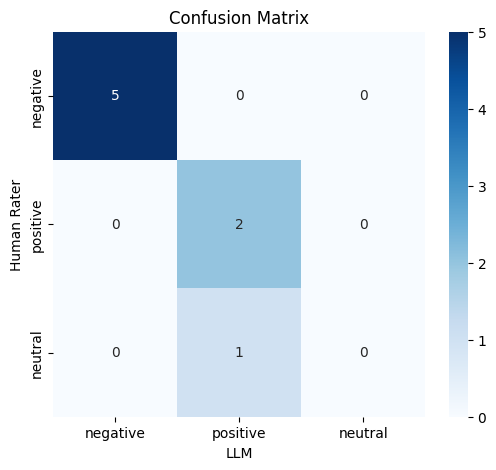

Cohen's Kappa: 0.7576
Matthews Correlation Coefficient: 0.7828


In [42]:


evaluate_rater_agreement(tuning_df["label"], "Human Rater", tuning_df["predicted_label"], "LLM")


#### Inspect disagreements

In [23]:
tuning_df[tuning_df["label"] != tuning_df["predicted_label"]][["pseudo_paragraph", "label", "predicted_label", "reasoning"]]

,pseudo_paragraph,label,predicted_label,reasoning
3,"The weather is nice today, perfect for a walk ...",neutral,positive,The post expresses enjoyment of the pleasant w...
